## Initializing polymer systems using a DPD potential
This notebook walks through the PhantomWalk functions for packing linear polymers in a box. The polymers are first placed in a cubic box using a random walk. Then a short HOOMD simulation is run with the soft force potential of Dissipative Particle Dynamics. The simulation ends when the pair energy from the DPD potential reaches a stable state, as checked with an autocorrelation function.

In [19]:
import sys
import os
sys.path.append('../lib/')
import create_system_dpd
from create_system_dpd import create_polymer_system_dpd
import matplotlib
import numpy as np  
import gsd, gsd.hoomd 
from cmeutils.sampling import is_equilibrated
import hoomd 
import time
import freud
import matplotlib_inline
import matplotlib.pyplot as plt
%matplotlib inline
matplotlib.style.use("ggplot")
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
import warnings
warnings.filterwarnings("ignore")
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

In [48]:
num_pol=10
num_mon=10
N = num_pol*num_mon
s = create_polymer_system_dpd(A=1000,gamma=800,k=20000,num_pol=num_pol,num_mon=num_mon,density=0.8,write=True,r_cut=1.13)
print(f"Finished in time = {s:.2f}s")

100

Running with A=1000, gamma=800, k=20000, num_pol=10, num_mon=10
Total build time:  0.00026108400197699666
Total build and simulation time: 0.7640095370006748
Finished in time = 0.76s


In [49]:
def calculate_pair_energy(A,r,r_cut,N):
    '''
    Calculate the minimum energy for the conservative force to reach at the given radius.
    energy for each pair in the system
    '''
    constant = (1/2)*A*r_cut
    pe = (A*(r**2))/(2*r_cut) - (A*r) + constant
    pair_energy = 13*pe/2

    return pair_energy
    
U = calculate_pair_energy(A=1000,r_cut=1.13,r=0.97,N=1000)
print(U)

73.62831858407128


## Visualize the Energy

Total steps 105100


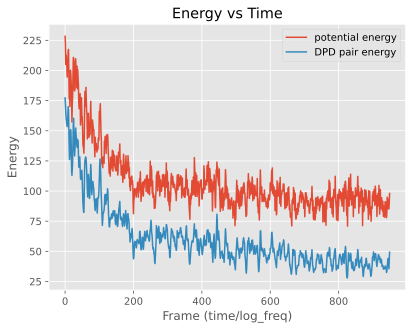

In [50]:
N=1000
log = np.genfromtxt("log.txt", names=True)
pe = log["mdcomputeThermodynamicQuantitiespotential_energy"]
bonds = log["mdbondHarmonicenergy"]
pairs = log["mdpairDPDenergy"]
print("Total steps",len(pe)*100+100)
cut = 100
plt.plot(pe[cut:], label="potential energy")
plt.plot(pairs[cut:], label="DPD pair energy")
plt.title("Energy vs Time")
plt.xlabel("Frame (time/log_freq)")
plt.ylabel("Energy")

plt.legend()

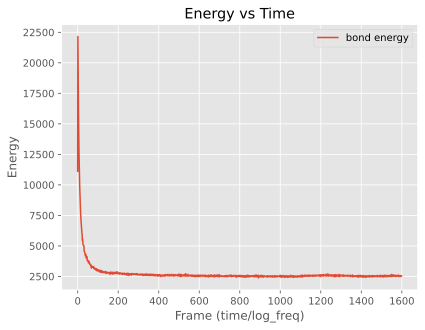

In [5]:
plt.plot(bonds, label="bond energy")
plt.title("Energy vs Time")
plt.xlabel("Frame (time/log_freq)")
plt.ylabel("Energy")

plt.legend()